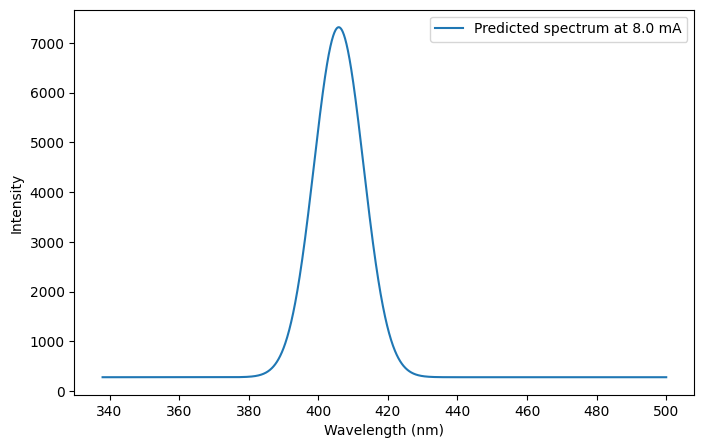

Peak Intensity: 7315.85
FWHM: 16.7428 nm


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Gaussian Model
def gaussian(lam, A, x0, sigma, offset):
    return A * np.exp(-(lam - x0)**2 / (2 * sigma**2)) + offset

# Fitted Parameter values
currents = np.array([2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28]) 
A_values = np.array([398.84, 1012.287, 1922.287, 7039.63, 20396.79, 47375.89, 10711.72, 14012.43, 19420.53, 29320.45, 50012.09, 57471.007, 67919.31, 64031.95])
x0_values = np.array([406.005, 405.65, 405.35, 405.87, 405.14, 405.81, 404.32, 404.21, 404.11, 403.87, 403.7, 403.71, 402.84, 403.37])
sigma_values = np.array([7.434, 7.277, 7.265, 7.11, 5.97, 6.83, 5.66, 5.04, 4.38, 3.597, 2.81, 2.196, 1.44, 1.29])
offset_values = np.array([213.634, 212.17, 207.73, 276.33, 377.179, 615.5, 278.41, 282.78, 329.96, 392.56, 441.28, 462.05, 529.36, 485.77])

# Interpolated parameter functions
A_of_I = interp1d(currents, A_values, kind="linear", fill_value="extrapolate")
x0_of_I = interp1d(currents, x0_values, kind="linear", fill_value="extrapolate")
sigma_of_I = interp1d(currents, sigma_values, kind="linear", fill_value="extrapolate")
offset_of_I = interp1d(currents, offset_values, kind="linear", fill_value="extrapolate")

# Final Model
def spectrum(lam, current):
    A = float(A_of_I(current))
    x0 = float(x0_of_I(current))
    sigma = float(sigma_of_I(current))
    offset = float(offset_of_I(current))

    A = max(A, 0)
    sigma = max(sigma, 1e-6)
    offset = max(offset, 0)

    I = gaussian(lam, A, x0, sigma, offset)
    return np.maximum(I, 0)

# Example usage
raw_input = input("Enter current in mA: ")
current_input = float(raw_input.lower().replace("ma", "").strip())

lam = np.linspace(338, 500, 2000)
intensity = spectrum(lam, current_input)

plt.figure(figsize=(8,5))
plt.plot(lam, intensity, label=f"Predicted spectrum at {current_input} mA")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity")
plt.legend()
plt.show()

fwhm_value = 2 * np.sqrt(2 * np.log(2)) * float(sigma_of_I(current_input))
peak_intensity = np.max(intensity)

print(f"Peak Intensity: {peak_intensity:.2f}")
print(f"FWHM: {fwhm_value:.4f} nm")